# Overview of the SHM Model

Hybrid models in Neural Hydrology generally consist of two core components:

* A Long Short-Term Memory (LSTM) neural network
* A process-based (or conceptual) hydrology model (PBM)

In this framework, the LSTM is trained to predict the input parameters of the PBM using the CAMELS-US dataset. These predicted values are often referred to as *conceptual parameters* or *conceptual inputs*, as they directly parameterize the PBM. Streamflow is then computed by passing these parameters through the PBM’s governing equations, alongside static catchment attributes from the dataset.

This Jupyter notebook demonstrates the full workflow for the Simple Hydrology Model (SHM), a hybrid model that couples an LSTM with the SHM PBM. It covers training, evaluation, and visualization. References to the original SHM formulation can be found in the docstrings of `neuralhydrology/modelzoo/SHM.py`.

In addition, we introduce two alternative approaches for producing final streamflow predictions:

* **Oracle Averaging Mode**
    * Uses a single set of parameters averaged over both the spin-up and prediction periods.
    * Assumes access to future information (hence the term "oracle").
* **Operational Averaging Mode**
    * Uses a single set of parameters averaged only over the spin-up period.
    * This is more realistic for deployment, since it relies only on past observations available at prediction time.

These approaches are designed for operational hydrology settings, where a single representative prediction may be more useful than a full time series. We compare them against the default NeuralHydrology output, referred to here as **Dynamic Mode**.

**Notes:**

* The CAMELS-US dataset is required to run this notebook.
* Configuration file paths must be adapted to your local environment.


# Imports

In [52]:
from pathlib import Path
import matplotlib.pyplot as plt
from neuralhydrology.nh_run import start_run, eval_run
import pickle

# Dynamic Mode

## Training SHM (Dynamic Mode)
Before proceeding, in `2basin-test-dynamic.yml`, please ensure to modify the paths to `train_basin_file`, `validation_basin_file`, `test_basin_file`, and `data_dir` to your specific file path.

In [8]:
# Start run begins a training run on the input configuration.
path_to_config = "2basin-test-dynamic.yml"
start_run(config_file= Path(path_to_config), gpu=-1) # We are just running on CPU, so -1.

2026-03-17 13:26:44,940: Logging to /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/example_SHM_dynamic_1703_132644/output.log initialized.
2026-03-17 13:26:44,941: ### Folder structure created at /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/example_SHM_dynamic_1703_132644
2026-03-17 13:26:44,941: ### Run configurations for example_SHM_dynamic
2026-03-17 13:26:44,941: experiment_name: example_SHM_dynamic
2026-03-17 13:26:44,942: train_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 13:26:44,942: validation_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 13:26:44,942: test_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 13:26:44,943: train_start_date: 2000-10-01 00:00:00
2026-03-17 13:26:44,944: train_end_date: 2014-09-30 00:00:00
2026-03-17 13:26:44,945: validation_start_date: 1990-10-01 00:00:00
2026-03-17 13:26:44,945:

## Testing SHM (Dynamic Mode)

In [8]:
run_dir_dynamic = "runs/example_SHM_dynamic_1703_132644/" # Modify this to your specific run path!
eval_run(run_dir=Path(run_dir_dynamic), period="test", gpu=-1)

2026-03-17 19:10:18,998: Using the model weights from runs/example_SHM_dynamic_1703_132644/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:02<00:00,  1.43s/it]

Removing overlapping predictions for hybrid model with predict_last_n > 1 on test period.
Collapses the results to generate a single continuous time series, consolidating data.

Removing overlapping internal_states and parameters for hybrid model with predict_last_n > 1 on test period.
Collapses the spin-up and prediction states/parameters into single continuous time series, consolidating data.

2026-03-17 19:10:21,880: Stored metrics at runs/example_SHM_dynamic_1703_132644/test/model_epoch010/test_metrics.csv
2026-03-17 19:10:21,881: Stored results at runs/example_SHM_dynamic_1703_132644/test/model_epoch010/test_results.p
2026-03-17 19:10:21,883: Stored states at runs/example_SHM_dynamic_1703_132644/test/model_epoch010/test

# Oracle Averaging Mode

## Training SHM (Oracle Averaging Mode)
Before proceeding, in `2basin-test-oracle.yml`, please ensure to modify the paths to `train_basin_file`, `validation_basin_file`, `test_basin_file`, and `data_dir` to your specific file path.

In [3]:
# Start run begins a training run on the input configuration.
path_to_config = "2basin-test-oracle.yml"
start_run(config_file= Path(path_to_config), gpu=-1) # We are just running on CPU, so -1.

2026-03-17 18:57:59,587: Logging to /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/example_SHM_oracle_average_1703_185759/output.log initialized.
2026-03-17 18:57:59,587: ### Folder structure created at /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/example_SHM_oracle_average_1703_185759
2026-03-17 18:57:59,588: ### Run configurations for example_SHM_oracle_average
2026-03-17 18:57:59,588: experiment_name: example_SHM_oracle_average
2026-03-17 18:57:59,588: train_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 18:57:59,588: validation_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 18:57:59,589: test_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 18:57:59,589: train_start_date: 2000-10-01 00:00:00
2026-03-17 18:57:59,589: train_end_date: 2014-09-30 00:00:00
2026-03-17 18:57:59,589: validation_start_date: 1990-10-01 00:00

2026-03-17 18:57:59,595: predict_last_n: 365
2026-03-17 18:57:59,595: seq_length: 910
2026-03-17 18:57:59,595: warmup_period: 180
2026-03-17 18:57:59,596: spin_up_period: 365
2026-03-17 18:57:59,596: num_workers: 8
2026-03-17 18:57:59,597: log_interval: 5
2026-03-17 18:57:59,597: log_tensorboard: True
2026-03-17 18:57:59,597: log_n_figures: 1
2026-03-17 18:57:59,597: save_weights_every: 1
2026-03-17 18:57:59,598: seed: 123
2026-03-17 18:57:59,598: dataset: camels_us
2026-03-17 18:57:59,599: data_dir: /home/adam/dev/repos/neuralhydrology-dcfe/data/CAMELS_US
2026-03-17 18:57:59,599: forcings: ['maurer', 'daymet', 'nldas']
2026-03-17 18:57:59,599: dynamic_inputs: ['PRCP(mm/day)_nldas', 'PRCP(mm/day)_maurer', 'prcp(mm/day)_daymet', 'srad(W/m2)_daymet', 'tmax(C)_daymet', 'tmin(C)_daymet', 'vp(Pa)_daymet']
2026-03-17 18:57:59,600: duplicate_features: ['PRCP(mm/day)_nldas', 'tmax(C)_daymet', 'tmin(C)_daymet', 'srad(W/m2)_daymet']
2026-03-17 18:57:59,600: dynamic_conceptual_inputs: ['PRCP(mm/d

## Testing SHM (Oracle Averaging Mode)

In [9]:
run_dir_oracle = "runs/example_SHM_oracle_average_1703_185759/" # Modify this to your specific run path!
eval_run(run_dir=Path(run_dir_oracle), period="test", gpu= -1)

2026-03-17 19:10:29,177: Using the model weights from runs/example_SHM_oracle_average_1703_185759/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:02<00:00,  1.44s/it]

Removing overlapping predictions for hybrid model with predict_last_n > 1 on test period.
Collapses the results to generate a single continuous time series, consolidating data.

Removing overlapping internal_states and parameters for hybrid model with predict_last_n > 1 on test period.
Collapses the spin-up and prediction states/parameters into single continuous time series, consolidating data.

2026-03-17 19:10:32,068: Stored metrics at runs/example_SHM_oracle_average_1703_185759/test/model_epoch010/test_metrics.csv
2026-03-17 19:10:32,069: Stored results at runs/example_SHM_oracle_average_1703_185759/test/model_epoch010/test_results.p
2026-03-17 19:10:32,072: Stored states at runs/example_SHM_oracle_average_1703_185

# Operational Averaging Mode

## Training SHM (Operational Averaging Mode)
Before proceeding, in `2basin-test-operational.yml`, please ensure to modify the paths to `train_basin_file`, `validation_basin_file`, `test_basin_file`, and `data_dir` to your specific file path.

In [4]:
# Start run begins a training run on the input configuration.
path_to_config = "2basin-test-operational.yml"
start_run(config_file= Path(path_to_config), gpu=-1) # We are just running on CPU, so -1.

2026-03-17 18:59:42,731: Logging to /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/example_SHM_operational_average_1703_185942/output.log initialized.
2026-03-17 18:59:42,731: ### Folder structure created at /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/runs/example_SHM_operational_average_1703_185942
2026-03-17 18:59:42,732: ### Run configurations for example_SHM_operational_average
2026-03-17 18:59:42,732: experiment_name: example_SHM_operational_average
2026-03-17 18:59:42,732: train_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 18:59:42,732: validation_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 18:59:42,732: test_basin_file: /home/adam/dev/repos/neuralhydrology-dcfe/examples/08-SHM/2_basin.txt
2026-03-17 18:59:42,733: train_start_date: 2000-10-01 00:00:00
2026-03-17 18:59:42,733: train_end_date: 2014-09-30 00:00:00
2026-03-17 18:59:42,734: validation_start_da

## Testing SHM (Operational Averaging Mode)

In [10]:
run_dir_operational = "runs/example_SHM_operational_average_1703_185942/" # Modify this to your specific run path!
eval_run(run_dir=Path(run_dir_operational), period="test", gpu=-1)

2026-03-17 19:10:39,339: Using the model weights from runs/example_SHM_operational_average_1703_185942/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:02<00:00,  1.42s/it]

Removing overlapping predictions for hybrid model with predict_last_n > 1 on test period.
Collapses the results to generate a single continuous time series, consolidating data.

Removing overlapping internal_states and parameters for hybrid model with predict_last_n > 1 on test period.
Collapses the spin-up and prediction states/parameters into single continuous time series, consolidating data.

2026-03-17 19:10:42,190: Stored metrics at runs/example_SHM_operational_average_1703_185942/test/model_epoch010/test_metrics.csv
2026-03-17 19:10:42,192: Stored results at runs/example_SHM_operational_average_1703_185942/test/model_epoch010/test_results.p
2026-03-17 19:10:42,196: Stored states at runs/example_SHM_operatio

# Visualization

We will only visualize for basin `0217700`, which per the CAMELS_US gauge metadata corresponds to CHATTOOGA RIVER NEAR CLAYTON, GA.

## Retrieving the data
* Streamflow Predictions are stored in `test_results.p`
* Conceptual Parameters and Internal States are stored in `test_all_output.p`

In [47]:
basin = '02177000' # Modify to '02349900' if you'd like to see the results for that basin.
with open(Path(run_dir_dynamic) / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    dynamic_shm_predictions = pickle.load(fp)
with open(Path(run_dir_oracle) / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    oracle_shm_predictions = pickle.load(fp)
with open(Path(run_dir_operational) / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    operational_shm_predictions = pickle.load(fp)
    

with open(Path(run_dir_dynamic) / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    dynamic_shm_all_output = pickle.load(fp)
with open(Path(run_dir_oracle) / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    oracle_shm_all_output = pickle.load(fp)
with open(Path(run_dir_operational) / "test" / "model_epoch010" / "test_all_output.p", "rb") as fp:
    operational_shm_all_output = pickle.load(fp)
    
# keys of prediction modes
prediction_mode_keys = ["Dynamic","Oracle Averaging","Operational Averaging"]
# grab keys of parmeters and internal states
param_keys = list(dynamic_shm_all_output[basin]["spinup_parameters"].keys())
state_keys = list(dynamic_shm_all_output[basin]["spinup_internal_states"].keys())

## Plotting SHM Predictions For All Modes

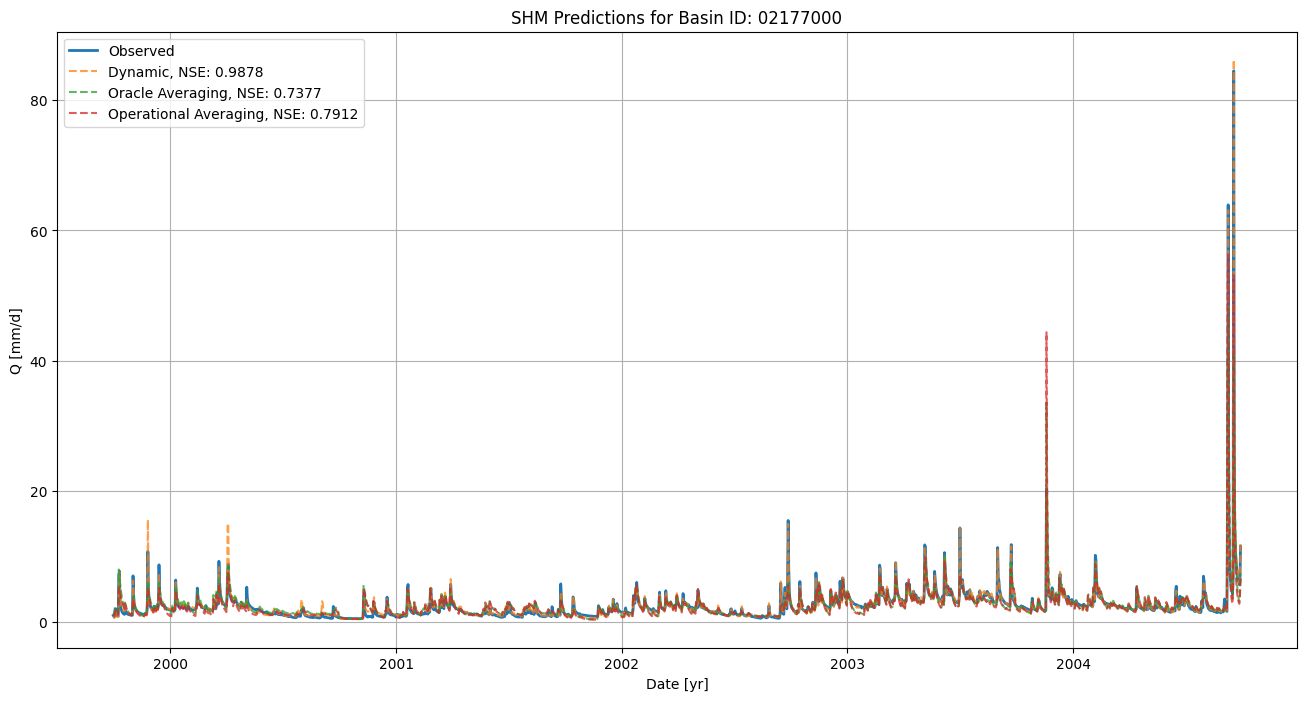

In [51]:
fig, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1)
dates = dynamic_shm_predictions[basin]["1D"]["xr"]["datetime"]
observed = dynamic_shm_predictions[basin]["1D"]["xr"]["QObs(mm/d)_obs"]
dynamic_nse = dynamic_shm_predictions[basin]["1D"]["NSE"]
oracle_nse = oracle_shm_predictions[basin]["1D"]["NSE"]
operational_nse = operational_shm_predictions[basin]["1D"]["NSE"]

ax.plot(dates,
        observed,
        label="Observed",
        linewidth=2)

ax.plot(dates,
        dynamic_shm_predictions[basin]["1D"]["xr"]["QObs(mm/d)_sim"],
        label=f"{prediction_mode_keys[0]}, NSE: {dynamic_nse:.4f}",
        linestyle="--",
        alpha=0.75)

ax.plot(dates,
        oracle_shm_predictions[basin]["1D"]["xr"]["QObs(mm/d)_sim"],
        label=f"{prediction_mode_keys[1]}, NSE: {oracle_nse:.4f}",
        linestyle="--",
        alpha=0.75)   

ax.plot(dates,
        operational_shm_predictions[basin]["1D"]["xr"]["QObs(mm/d)_sim"],
        label=f"{prediction_mode_keys[2]}, NSE: {operational_nse:.4f}",
        linestyle="--",
        alpha=0.75)

ax.set_ylabel("Q [mm/d]")
ax.set_xlabel("Date [yr]")
ax.set_title(f"SHM Predictions for Basin ID: {basin}")
ax.legend()
ax.grid()

## Plotting SHM Conceptual Parameters For All Modes

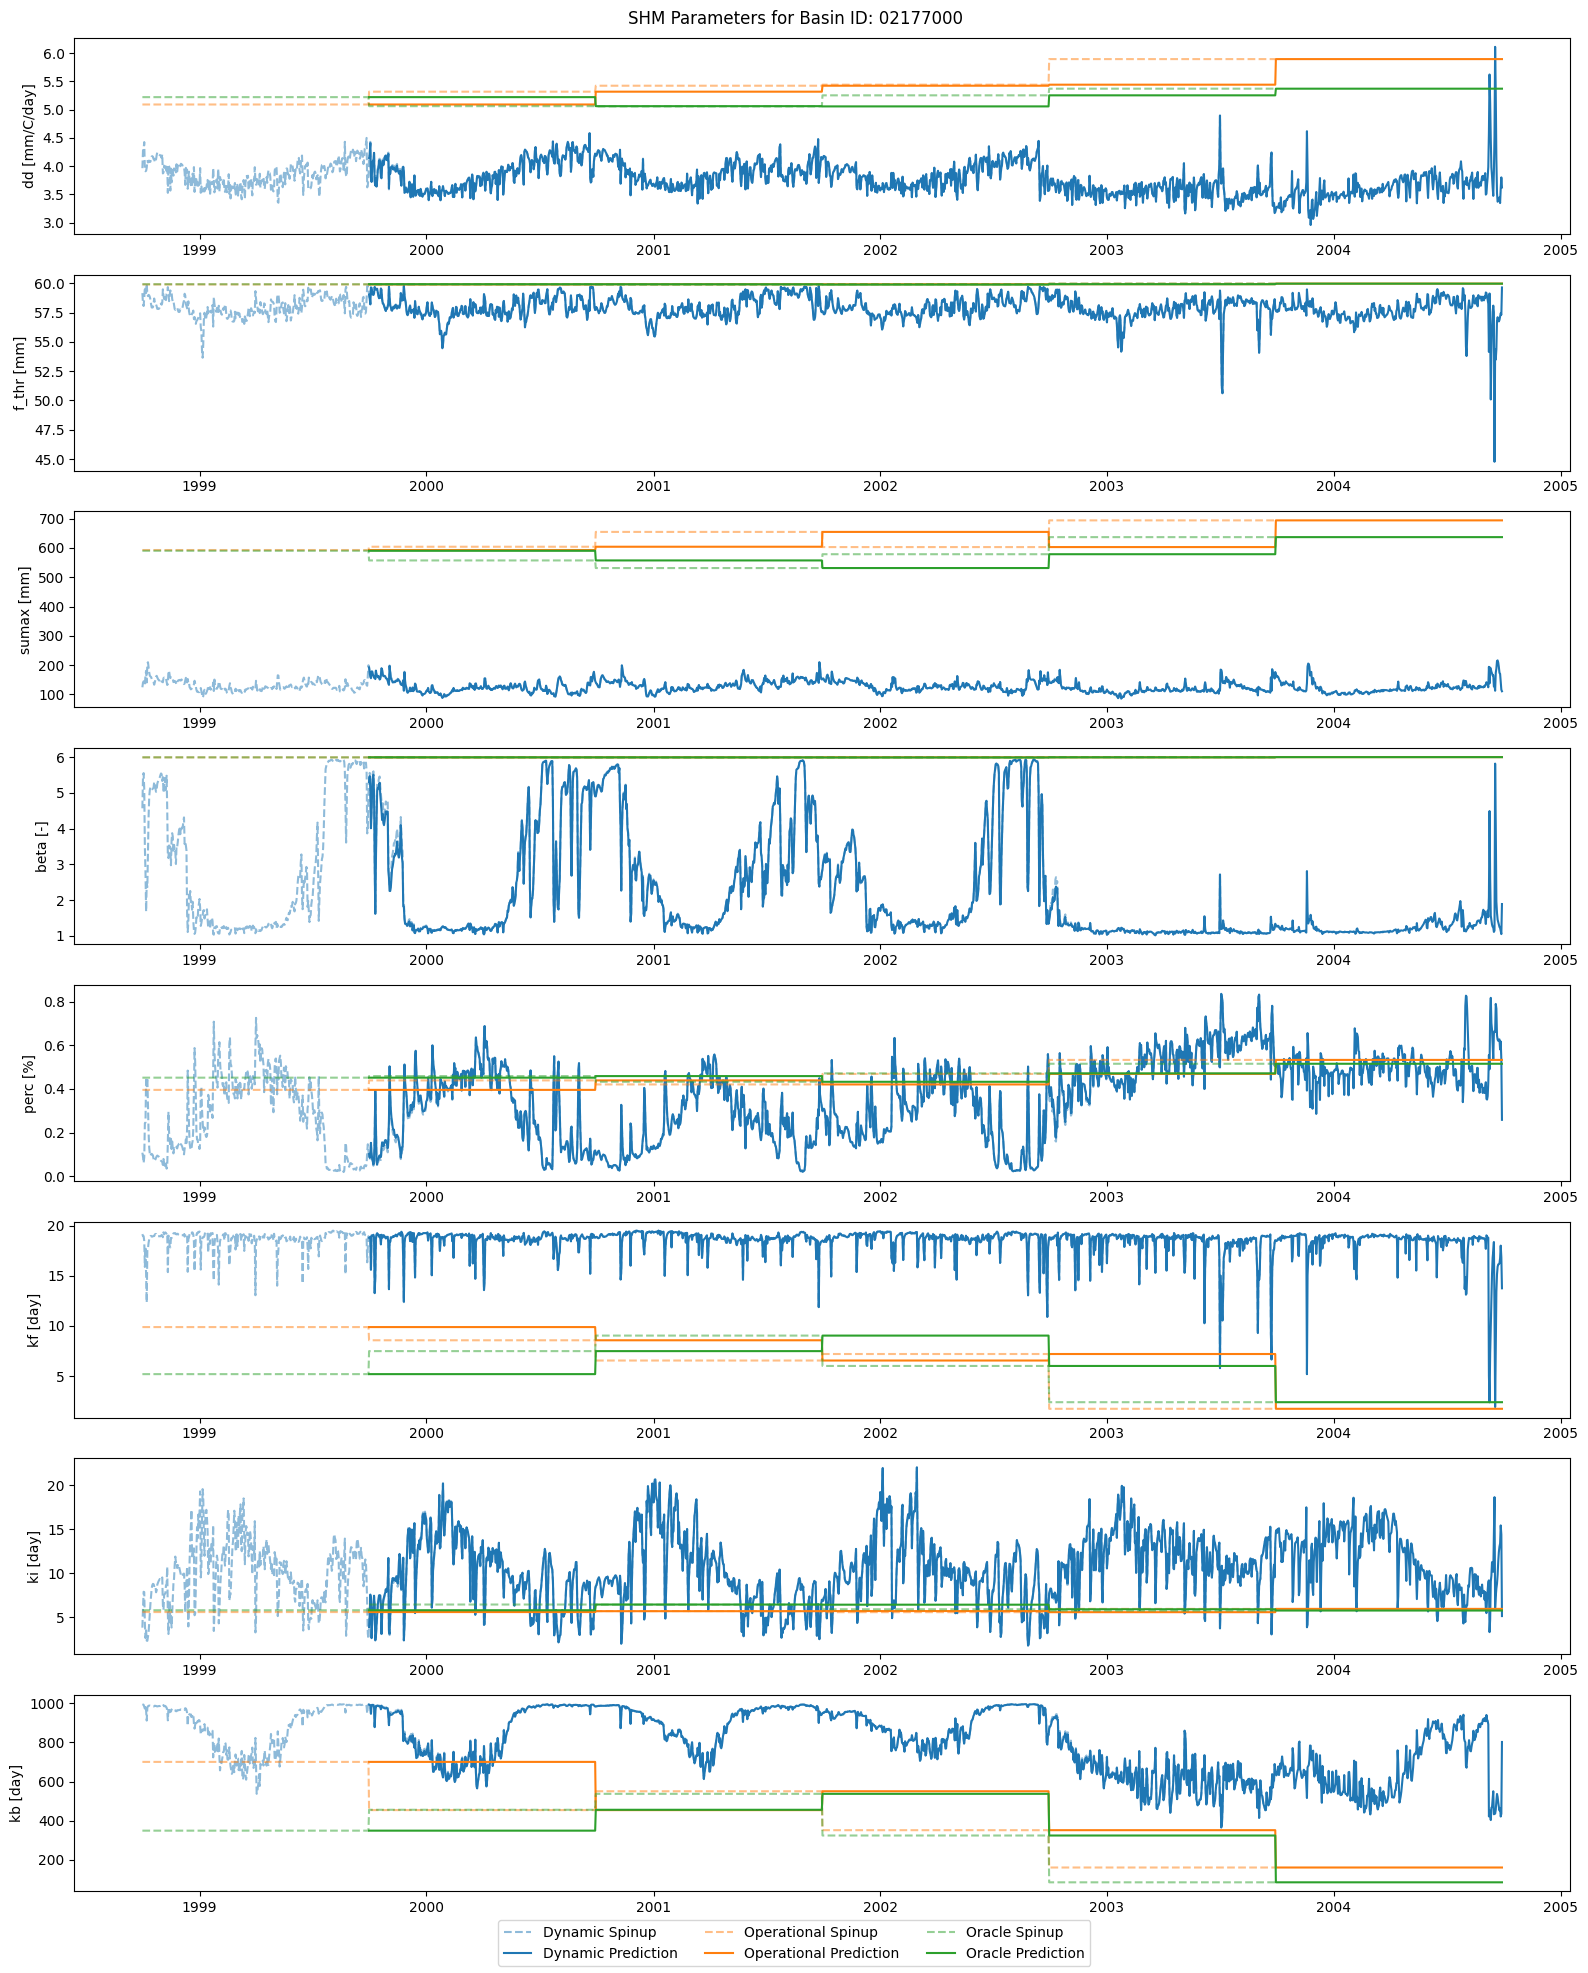

In [49]:
param_unit_keys = ['[mm/C/day]', '[mm]', '[mm]', '[-]', '[%]', '[day]', '[day]', '[day]']
param_dates = dynamic_shm_all_output['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(param_keys)), nrows=len(param_keys), ncols=1)
for i, param_interest in enumerate(param_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(param_dates, dynamic_shm_all_output[basin]["spinup_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, dynamic_shm_all_output[basin]["prediction_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(param_dates, operational_shm_all_output[basin]["spinup_parameters"][param_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, operational_shm_all_output[basin]["prediction_parameters"][param_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(param_dates, oracle_shm_all_output[basin]["spinup_parameters"][param_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, oracle_shm_all_output[basin]["prediction_parameters"][param_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{param_interest} {param_unit_keys[i]}")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"SHM Parameters for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

## Plotting SHM Internal States For All Modes

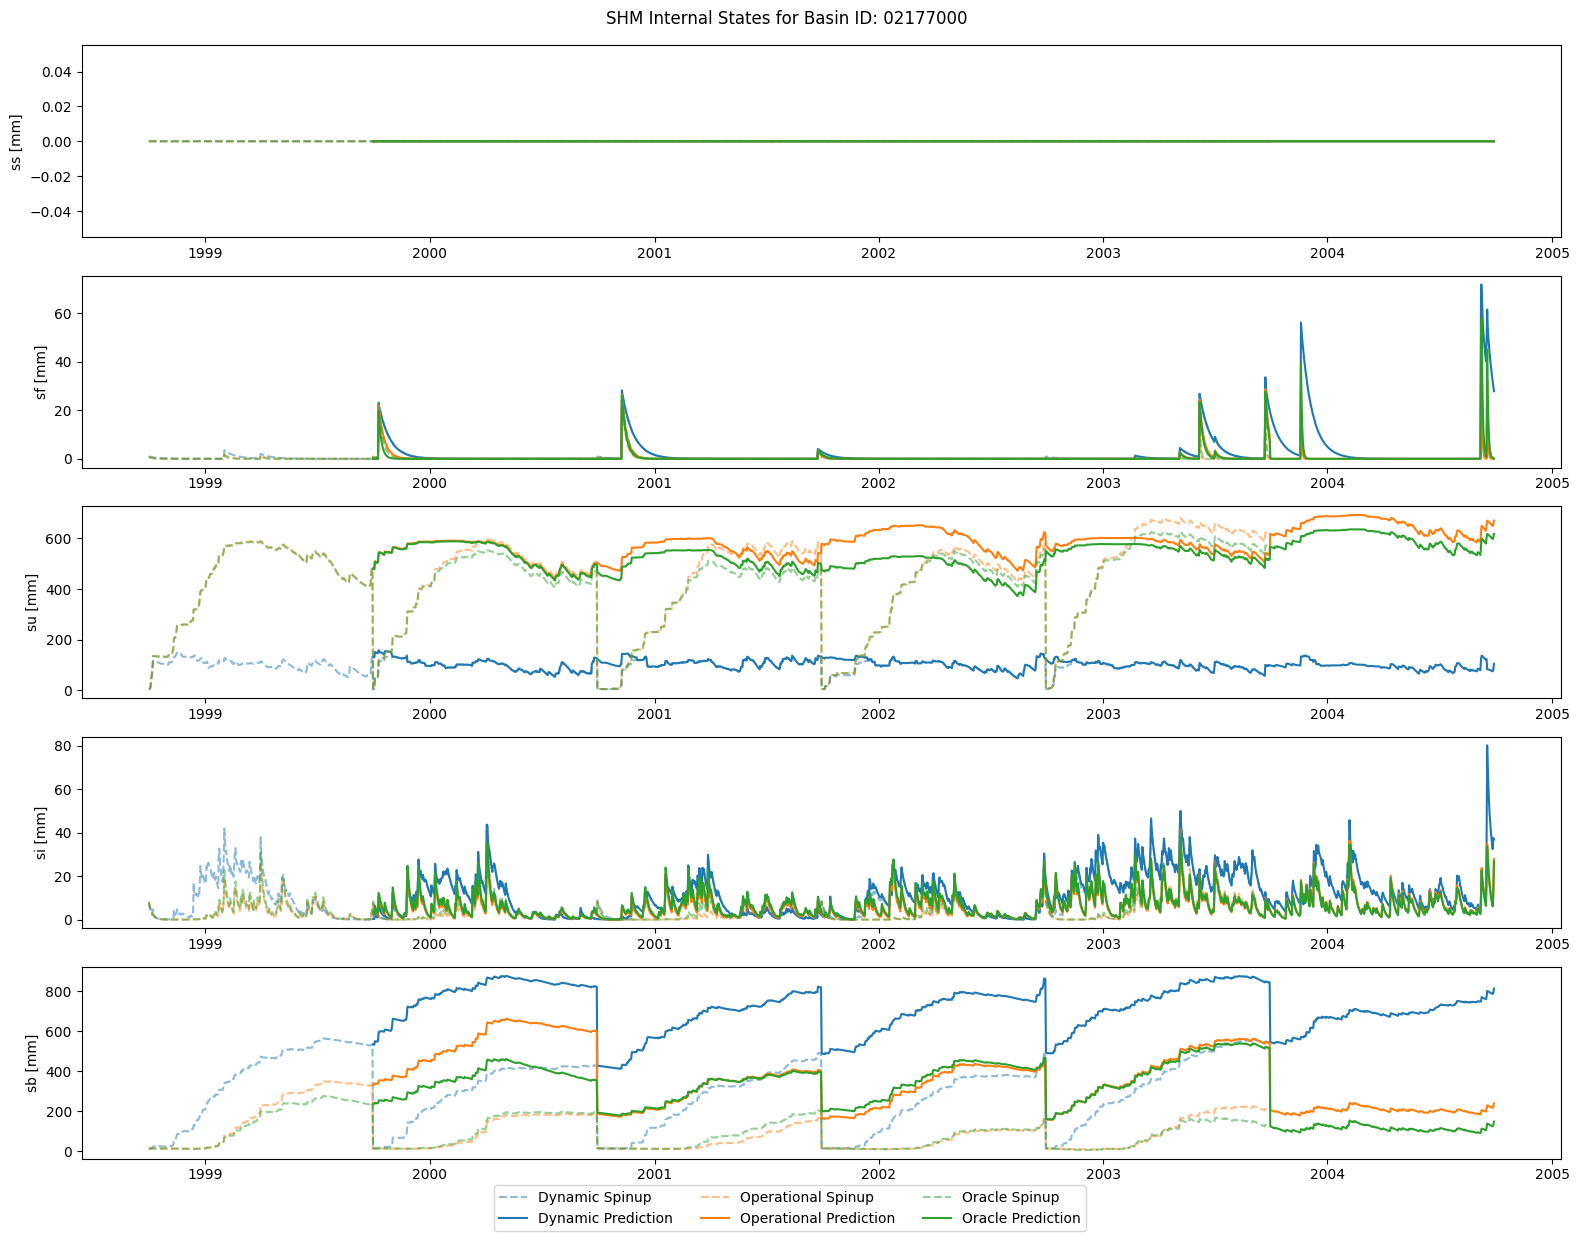

In [50]:
state_dates = dynamic_shm_all_output['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(state_keys)), nrows=len(state_keys), ncols=1)
for i, state_interest in enumerate(state_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(state_dates, dynamic_shm_all_output[basin]["spinup_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(state_dates, dynamic_shm_all_output[basin]["prediction_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(state_dates, operational_shm_all_output[basin]["spinup_internal_states"][state_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(state_dates, operational_shm_all_output[basin]["prediction_internal_states"][state_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(state_dates, oracle_shm_all_output[basin]["spinup_internal_states"][state_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(state_dates, oracle_shm_all_output[basin]["prediction_internal_states"][state_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{state_interest} [mm]")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"SHM Internal States for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.03, 1, 0.99])